In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os
import pandas as pd
from collections import defaultdict

from glob import glob
from PIL import Image
import random

### RND Model with seed

In [2]:
# Seed fixed to make RND model initialisation and permutation tests reproducible.
seed = 108
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [ ]:
class RunningNorm(nn.Module):
    """Running-statistics normaliser initialised from early observations."""
    def __init__(self, shape, epsilon=1e-5, clip_range=5.0):
        super().__init__()
        self.register_buffer('mean', torch.zeros(shape))
        self.register_buffer('var', torch.ones(shape))
        self.register_buffer('count', torch.tensor(epsilon))
        self.clip_range = clip_range

    @torch.no_grad()
    def update(self, x):
        batch_mean = x.mean(dim=0)
        batch_var = x.var(dim=0, unbiased=False)
        batch_count = x.size(0)

        delta = batch_mean - self.mean
        total_count = self.count + batch_count

        new_mean = self.mean + delta * batch_count / total_count
        m_a = self.var * self.count
        m_b = batch_var * batch_count
        M2 = m_a + m_b + (delta**2) * self.count * batch_count / total_count
        new_var = M2 / total_count

        self.mean.copy_(new_mean)
        self.var.copy_(new_var)
        self.count.copy_(total_count)

    def forward(self, x):
        x_norm = (x - self.mean) / torch.sqrt(self.var + 1e-8)
        x_clipped = torch.clamp(x_norm, -self.clip_range, self.clip_range)
        return x_clipped


# %%
class RNDConvModel(nn.Module):
    """Convolutional model used for Random Network Distillation."""
    def __init__(self, input_channels=3, output_dim=512, obs_norm=None):
        super().__init__()
        if obs_norm is None:
            self.obs_norm = RunningNorm((input_channels, 32, 32))
        else:
            self.obs_norm = obs_norm
        self.conv = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=4, stride=2),  # 32 → 15
            nn.LeakyReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),              # 15 → 6
            nn.LeakyReLU(),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 6 * 6, output_dim)
        )

    def forward(self, x):
        x = self.obs_norm(x)
        x = self.conv(x)
        return self.fc(x)

    def update_obs_norm(self, x):
        self.obs_norm.update(x)

In [ ]:
def run_rnd_training(image_data):
    """
    Trains the RND predictor network on navigation image frames and returns
    frame-wise intrinsic reward (curiosity) scores.
    Uses participant-specific predictor, target, normalizers, and optimizer
    initialized in the main loop below.
    """
    all_intrinsic_rewards = []
    cumulative_reward = 0
    cumulative_intrinsic = []
    all_images_with_rewards = []
    obs_batch = []

    # === Pre-step: Update observation normalization ===
    for img_array, _ in image_data[:5]:
        obs_batch.append(torch.FloatTensor(img_array).unsqueeze(0))

    obs_batch_tensor = torch.cat(obs_batch, dim=0)  # Shape: [N, 3, 32, 32]

    # Initialize both normalizers with the same data
    obs_norm_predictor.update(obs_batch_tensor)
    obs_norm_target.update(obs_batch_tensor)

    # === Main RND predictor training ===
    for img_array, path in image_data:
        obs_tensor = torch.FloatTensor(img_array).unsqueeze(0)

        # Separate normalization for predictor and target
        obs_tensor_pred = obs_norm_predictor(obs_tensor)
        obs_tensor_tgt = obs_norm_target(obs_tensor)

        # Forward passes
        with torch.no_grad():
            target_feat = target(obs_tensor_tgt)
        pred_feat = predictor(obs_tensor_pred)

        # Compute intrinsic reward
        intrinsic_reward = ((pred_feat - target_feat) ** 2).mean().item()
        all_intrinsic_rewards.append(intrinsic_reward)
        cumulative_reward += intrinsic_reward
        cumulative_intrinsic.append(cumulative_reward)

        # Save image, path, and reward for inspection
        all_images_with_rewards.append((img_array, path, intrinsic_reward))

        # Train predictor
        loss = ((pred_feat - target_feat) ** 2).mean()
        rnd_optimizer.zero_grad()
        loss.backward()
        rnd_optimizer.step()

    return all_intrinsic_rewards, cumulative_intrinsic, all_images_with_rewards

In [ ]:
def load_preprocessed_images(folder, extension="png"):
    """
    Loads image frames, converts them to RGB, normalizes pixel values to [0, 1],
    and rearranges them into PyTorch channels-first format: (C, H, W).
    """

    frame_paths = sorted(glob(os.path.join(folder, f"*.{extension}")))  # ← only loads `.png` files
    image_data = []

    for path in frame_paths:
        try:
            img = Image.open(path).convert("RGB")
            img_array = np.array(img, dtype=np.float32) / 255.0
            img_array = np.transpose(img_array, (2, 0, 1))  # (3, H, W)
            image_data.append((img_array, path))
        except Exception as e:
            print(f"Failed to load {path}: {e}")

    return image_data

### Data

In [ ]:
# === SETTINGS ===
counterbalancing = "/path/to/counterbalancing.xlsx"
image_root = "/path/to/processed_screenshots"

# === LOAD PARTICIPANT METADATA ===
metadata = pd.read_excel(counterbalancing)
novel_first = metadata[metadata['WhatFirst'] == 'novel']['Subject'].astype(int).tolist()
familiar_first = metadata[metadata['WhatFirst'] == 'familiar']['Subject'].astype(int).tolist()

novel_day1_ids = [f"sub-{str(s).zfill(3)}" for s in novel_first]
familiar_day1_ids = [f"sub-{str(s).zfill(3)}" for s in familiar_first]

exclusion_list = []

# === LIST PARTICIPANT FOLDERS ===
raw_participants = sorted(glob(os.path.join(image_root, "sub*")))

# Normalize to dict: {sub_id: full_path}
participants = {}
for path in raw_participants:
    folder_name = os.path.basename(path)
    digits = ''.join(filter(str.isdigit, folder_name))
    sub_id = f"sub-{int(digits):03d}"
    participants[sub_id] = path
print(len(participants))

34


### Training loop

In [ ]:
# === Loop over participants ===
for sub_id, sub_path in participants.items():
    if sub_id in exclusion_list:
        continue

    print(f"\n▶ Processing {sub_id}")

    # === Define output check paths ===
    output_dir = "/path/to/the/output/file"
    rnd_path = os.path.join(output_dir, f"rnd_model_{sub_id}.pth")

    expected_conditions = ["familiarisation", "novel", "familiar"]
    missing = []

    for cond in expected_conditions:
        p = os.path.join(output_dir, f"{sub_id}_{cond}_rewards_wSEED.csv")
        if not os.path.exists(p):
            missing.append(p)

    # Only check the single rnd_path file (don't iterate over the string)
    if not os.path.exists(rnd_path):
        missing.append(rnd_path)

    if not missing:
        print(f"All output files already exist for {sub_id} — skipping.")
        continue
    else:
        print("Missing:", *missing, sep="\n  - ")

    # === Determine condition ordering ===
    if sub_id in novel_day1_ids:
        conditions = [("novel", "session2"), ("familiar", "day2")]
    else:
        conditions = [("familiar", "session2"), ("novel", "day2")]

    conditions.insert(0, ("familiarisation", "session1"))

    # Normalise and initialise predictor and target networks 
    obs_norm_predictor = RunningNorm((3, 32, 32))
    obs_norm_target = RunningNorm((3, 32, 32))
    target = RNDConvModel(input_channels=3, obs_norm=obs_norm_target)
    predictor = RNDConvModel(input_channels=3, obs_norm=obs_norm_predictor)
    for param in target.parameters():
        param.requires_grad = False
    rnd_optimizer = optim.Adam(predictor.parameters(), lr=1e-3)

    # === COLLECT IMAGES + TRACK CONDITION PER FRAME ===
    image_data = []
    image_labels = []

    for cond_name, folder in conditions:
        print(f"  {cond_name.title()} ({folder})")

        frame_dir = os.path.join(sub_path, folder)
        if not os.path.exists(frame_dir):
            print(f"      Missing folder: {frame_dir}")
            continue

        imgs = load_preprocessed_images(frame_dir)
        if len(imgs) == 0:
            print(f"      No images found in {frame_dir}")
            continue

        image_data.extend([img for img, _ in imgs])
        image_labels.extend([(cond_name, path) for _, path in imgs])

    if len(image_data) == 0:
        print(f"No images found for any condition in {sub_id} — skipping RND")
        continue

    # === RUN RND TRAINING ===
    rewards, cumulative, _ = run_rnd_training(list(zip(image_data, [p for _, p in image_labels])))

    # === GROUP & SAVE REWARDS PER CONDITION ===
    cond_rewards = defaultdict(list)

    for (cond_name, frame_path), reward in zip(image_labels, rewards):
        cond_rewards[cond_name].append({'frame_path': frame_path, 'reward': reward})

    for cond_name, entries in cond_rewards.items():
        reward_df = pd.DataFrame(entries)
        csv_path = os.path.join(output_dir, f"{sub_id}_{cond_name}_rewards_wSEED.csv")
        reward_df.to_csv(csv_path, index=False)
        print(f"    Saved rewards: {csv_path}")

    # === SAVE MODEL AND OBS_NORM FOR FEATURE EXTRACTION ===
    predictor.eval()
    target.eval()
    for param in predictor.parameters():
        param.requires_grad = False
    for param in target.parameters():
        param.requires_grad = False

    rnd_path = os.path.join(output_dir, f"rnd_model_{sub_id}.pth")
    torch.save({
        'predictor_state_dict': predictor.state_dict(),
        'target_state_dict': target.state_dict(),
        'obs_norm_state_dict': predictor.obs_norm.state_dict(),
        'model_class': 'RNDConvModel',
        'input_channels': 3,
    }, rnd_path)

    print(f"    Saved RND model and curiosity scores for participant {sub_id}")

### Creating files with both EEG & curiosity scores

In [ ]:
# Load and normalize Excel metadata
metadata.columns = metadata.columns.str.strip()
metadata = metadata.dropna(subset=["Subject"])
metadata["sub_id"] = metadata["Subject"].apply(lambda x: f"sub-{int(x):03d}")

participants = metadata["sub_id"].tolist()

# Paths to your data folders
base_reward_dir = "/path/to/the/curiosity/data"
base_theta_dir = "/path/to/the/EEG/data"


In [ ]:
condition_map = {}

for _, row in metadata.iterrows():
    sub_id = row["sub_id"]
    what_first = row["WhatFirst"]

    if what_first == "novel":
        eeg_map = {
            "familiarisation": {"session": "DAY1", "file": "navigateEEG"},
            "novel": {"session": "DAY1", "file": "navigateEEG2"},
            "familiar": {"session": "DAY2", "file": "navigateEEG"},
        }
    else:  # what_first == "familiar"
        eeg_map = {
            "familiarisation": {"session": "DAY1", "file": "navigateEEG"},
            "familiar": {"session": "DAY1", "file": "navigateEEG2"},
            "novel": {"session": "DAY2", "file": "navigateEEG"},
        }

    condition_map[sub_id] = eeg_map


In [ ]:
def get_theta_path(sub_id, cond_name):
    """Returns EEG theta-data path for a participant and condition."""
    try:
        mapping = condition_map[sub_id][cond_name]
        session = mapping["session"]
        file_key = mapping["file"]
        filename = f"{sub_id.replace('-', '_')}_{file_key}_cont_ICA_raw_hilbert.npy"

        theta_path = os.path.join(
            base_theta_dir,
            sub_id,
            f"{sub_id}_ses-{session}",
            "continuous_processed",
            filename
        )
        return theta_path
    except KeyError:
        return None


In [ ]:
clusters = ["frontal"]
valid_pairs = []

for sub_id in participants:
    for cond in ["familiarisation", "novel", "familiar"]:
        reward_file = os.path.join(base_reward_dir, f"{sub_id}_{cond}_rewards_wSEED.csv")
        if not os.path.exists(reward_file):
            print(f"Missing reward file: {reward_file}")
            continue

        try:
            rewards = pd.read_csv(reward_file)["reward"].values
        except Exception as e:
            print(f"Failed to load rewards for {sub_id} {cond}: {e}")
            continue

        base_path = get_theta_path(sub_id, cond)
        if base_path is None:
            print(f"get_theta_path returned None for {sub_id} {cond}")
            continue

        cluster_paths = {}
        cluster_data = {}
        cluster_lengths_match = True

        for cluster in clusters:
            if cluster == "frontal":
                theta_path = base_path
            else:
                theta_path = base_path.replace("_raw_hilbert.npy", f"_raw_{cluster}_hilbert.npy")

            if not os.path.exists(theta_path):
                print(f"Missing {cluster} theta file: {theta_path}")
                cluster_lengths_match = False
                break

            try:
                theta = np.load(theta_path)
            except Exception as e:
                print(f"Failed to load {theta_path}: {e}")
                cluster_lengths_match = False
                break

            if theta.ndim != 1:
                print(f"Unexpected shape in {cluster}: {theta.shape}")
                cluster_lengths_match = False
                break

            cluster_paths[cluster] = theta_path
            cluster_data[cluster] = theta

        if not cluster_lengths_match:
            continue

        min_len = min([len(rewards)] + [len(arr) for arr in cluster_data.values()])
        rewards = rewards[:min_len]
        for cluster in clusters:
            cluster_data[cluster] = cluster_data[cluster][:min_len]

        print(f"Valid match for {sub_id} {cond} | {min_len} timepoints")
        valid_pairs.append({
            "participant": sub_id,
            "condition": cond,
            "reward_file": reward_file,
            "n_rewards": len(rewards),
            **{f"{c}_theta_file": cluster_paths[c] for c in clusters}
        })

# Save to CSV
df = pd.DataFrame(valid_pairs)
df.to_csv("/path/to/the/output/file/valid_reward_theta_cluster_pairs_wSEED.csv", index=False)
print(f"Saved {len(valid_pairs)} valid cluster-level pairs to valid_reward_theta_cluster_pairs_wSEED.csv")

In [ ]:
# Constants
sfreq = 250  # adjust if different

condition_map = {
    "familiarisation": 0,
    "novel": 1,
    "familiar": 2
}

# Load valid pairs
valid_df = pd.read_csv("/path/to/the/file/valid_reward_theta_cluster_pairs_wSEED.csv")

participants = sorted(valid_df["participant"].unique())
participant_idx_map = {p: i for i, p in enumerate(participants)}

# Infer number of participants instead of hardcoding 31
n_participants = len(participants)
n_conditions = 3
n_streams = 2    # 0 = EEG, 1 = reward
max_len = 150

# Initialize output array: (participant, condition, eeg/reward, time)
results_file = np.zeros((n_participants, n_conditions, n_streams, max_len))

for _, row in valid_df.iterrows():
    participant = row["participant"]
    cond_name = row["condition"]
    cond = condition_map[cond_name]

    reward_path = row["reward_file"]
    theta_path = row["frontal_theta_file"]  # or other cluster as needed

    # Load reward data
    reward_df = pd.read_csv(reward_path)
    rewards = reward_df["reward"].to_numpy()

    # Load EEG data
    eeg_theta = np.load(theta_path)

    # Downsample EEG to 1 Hz (average within each second)
    n_full_seconds = eeg_theta.shape[0] // sfreq
    eeg_theta_avg = eeg_theta[:n_full_seconds * sfreq].reshape(n_full_seconds, sfreq).mean(axis=1)

    # Match lengths
    if len(rewards) > len(eeg_theta_avg):
        print(f"Warning: More reward samples than EEG seconds for {participant}, condition {cond_name}. Trimming rewards.")

    n_trim = min(len(rewards), len(eeg_theta_avg))

    eeg_data = eeg_theta_avg[:n_trim]
    curiosity_data = rewards[:n_trim]

    # Truncate to 150 max
    if n_trim > max_len:
        eeg_data = eeg_data[:max_len]
        curiosity_data = curiosity_data[:max_len]
        n_trim = max_len

    p_idx = participant_idx_map[participant]

    # Store into big array
    results_file[p_idx, cond, 0, :n_trim] = eeg_data
    results_file[p_idx, cond, 1, :n_trim] = curiosity_data

# Save
np.savez(
    "/path/to/the/output/file/frontal_with_ids_wSEED.npz",
    data=results_file,
    participants=np.array(participants)
)
print(f"Saved array of shape {results_file.shape} with {n_participants} participants.")

### Predicting frontal theta from curiosity scores

In [9]:
from scipy.stats import zscore
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
from scipy.ndimage import uniform_filter1d, gaussian_filter1d
import seaborn as sns

data = np.load("/Users/elisa/Documents/ResMas/Thesis/results_files/for_thirza_with_ids.npz")
data = data['data']

'''
0 = Familiarisation
1 = Novel
2 = Familiar
'''

'\n0 = Familiarisation\n1 = Novel\n2 = Familiar\n'

In [10]:

smoothing_factor = 2
alphas = [0.1, 1.0, 10.0, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10]

n_participants = data.shape[0]
r2_scores = np.zeros((n_participants, 3))

best_alphas = np.zeros((n_participants, 3))

for participant in range(n_participants):
    for condition in range(3):

        # z-score and smooth
        curiosity = zscore(data[participant, condition, 1])
        theta = uniform_filter1d(zscore(data[participant, condition, 0, :]), size=2)

        theta = gaussian_filter1d(theta, sigma=smoothing_factor)
        curiosity = gaussian_filter1d(curiosity, sigma=smoothing_factor)

        # ridge regression with CV
        X = curiosity.reshape(-1, 1)
        y = theta
        model = RidgeCV(alphas=alphas)
        model.fit(X, y)
        y_pred = model.predict(X)
        r2_scores[participant, condition] = r2_score(y, y_pred)
        best_alphas[participant, condition] = model.alpha_

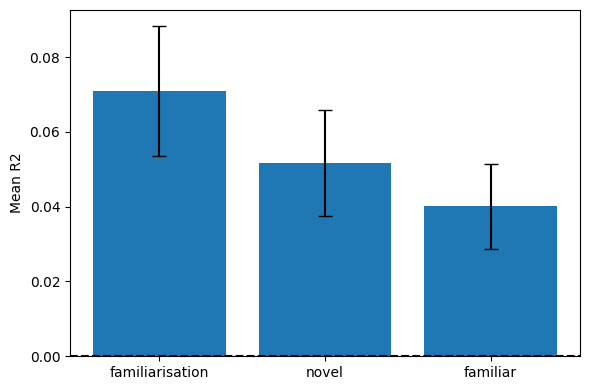

In [ ]:
'''mean r2 scores across participants'''

means = np.mean(r2_scores, axis=0)
sems = np.std(r2_scores, axis=0) / np.sqrt(r2_scores.shape[0])  # SEM = SD / sqrt(n)

conditions = ["familiarisation", "novel", "familiar"]
x = np.arange(len(conditions))
plt.figure(figsize=(6, 4))
plt.bar(x, means, yerr=sems, capsize=5)
plt.axhline(0, color='k', linestyle='--')
plt.xticks(x, conditions)
plt.ylabel("Mean R2")
plt.tight_layout()
plt.show()

In [12]:
means

array([0.07085201, 0.05175883, 0.04007938])

/var/folders/0g/96l4f6ds27lf3rsg94jy7c4c0000gn/T/ipykernel_7213/2024471127.py:25: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


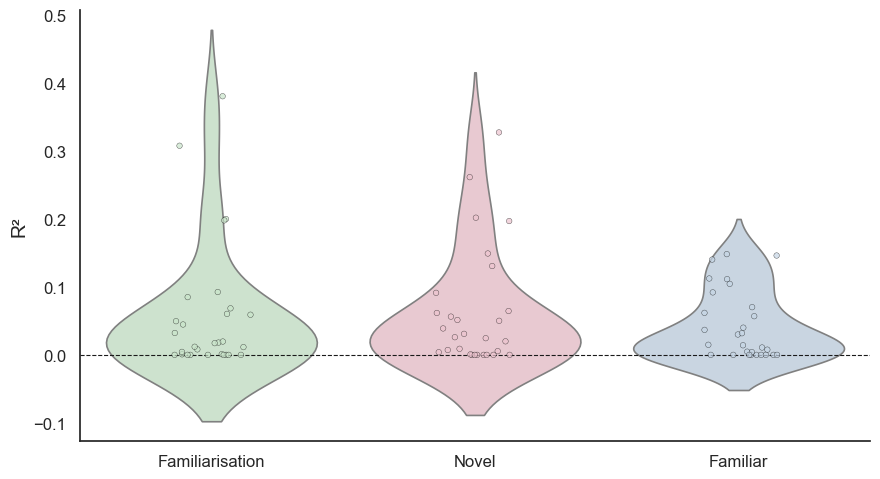

In [ ]:
''' visualising condition-level R² values across participants with a violin plot '''

# Set seaborn style
sns.set_theme(style="white", font_scale=1.1)

# === Prepare Data ===
# Assumes r2_scores is shaped (n_subjects, 3)
condition_labels = ["Familiarisation", "Novel", "Familiar"]
n_subjects = r2_scores.shape[0]

df = pd.DataFrame({
    "R2": r2_scores.flatten(),
    "Condition": np.repeat(condition_labels, n_subjects),
    "Cluster": np.repeat(condition_labels, n_subjects)  # to control hue color
})

# === Custom color palette ===
custom_palette = {
    'Familiarisation': "#CAE5CB",  # soft green
    'Novel': "#EDC4CF",            # soft rose
    'Familiar': "#C5D5E5"          # soft blue
}

# === Plot ===
fig, ax = plt.subplots(figsize=(9, 5))

sns.violinplot(
    data=df,
    x='Condition',
    y='R2',
    hue='Cluster',
    palette=custom_palette,
    inner=None,
    linewidth=1.2,
    scale='width',
    dodge=False
)

sns.stripplot(
    data=df,
    x='Condition',
    y='R2',
    hue='Cluster',
    dodge=False,
    palette=custom_palette,
    alpha=0.7,
    jitter=0.15,
    size=4,
    edgecolor='black',
    linewidth=0.3,
    ax=ax
)

# Clean up duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))

ax.legend(
    unique.values(),
    unique.keys(),
    title="",
    frameon=False,
    fontsize=11,
    title_fontsize=12,
    handlelength=1.5,
    handletextpad=0.8,
    loc='upper left',
    borderaxespad=0.2
)

# Styling
ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax.set_ylabel("R²", fontsize=14)
ax.set_xlabel("")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.despine(top=True, right=True)

plt.tight_layout()
#plt.savefig("/path/to/the/Graphs/r2_violin_by_condition_central.png", dpi=600)
plt.show()


In [ ]:
# PERMUTATION test
n_permutations = 1000   # 1000 permutations per participant, per condition
r2_null = np.zeros((n_participants, 3, n_permutations))

for participant in range(n_participants):
    for condition in range(3):
        x = zscore(data[participant, condition, 1])                              # curiosity
        y = uniform_filter1d(zscore(data[participant, condition, 0, :]), size=2) # theta
        y = gaussian_filter1d(y, sigma=smoothing_factor)
        x = gaussian_filter1d(x, sigma=smoothing_factor)
        for perm in range(n_permutations):
            x_shuffled = np.random.permutation(x).reshape(-1, 1)
            model = RidgeCV(alphas=alphas)
            model.fit(x_shuffled, y)
            y_pred = model.predict(x_shuffled)
            r2_null[participant, condition, perm] = r2_score(y, y_pred)

In [15]:
p_values = np.mean(r2_null >= r2_scores[:, :, None], axis=2)
print("\nP-values (real vs. permuted):")
print(np.round(p_values, 3))


P-values (real vs. permuted):
[[0.99  0.708 0.001]
 [0.348 0.893 0.   ]
 [0.78  0.273 0.077]
 [0.005 0.177 0.543]
 [0.114 0.093 0.031]
 [0.002 0.003 0.   ]
 [0.    0.002 0.114]
 [0.    0.    0.01 ]
 [0.075 0.302 0.304]
 [0.505 0.548 0.675]
 [0.    0.223 0.005]
 [0.002 0.182 0.64 ]
 [0.074 0.803 0.313]
 [0.    0.044 0.884]
 [0.    0.    0.969]
 [0.012 0.005 0.21 ]
 [0.933 0.003 0.042]
 [0.215 0.    0.   ]
 [0.028 0.    0.512]
 [0.    0.012 0.58 ]
 [0.452 0.    0.003]
 [0.875 0.715 0.001]
 [0.    0.491 0.703]
 [0.    0.    0.222]
 [0.004 0.53  0.   ]
 [0.018 0.211 0.292]
 [0.118 0.766 0.128]
 [0.035 0.    0.029]
 [0.007 0.374 0.116]]


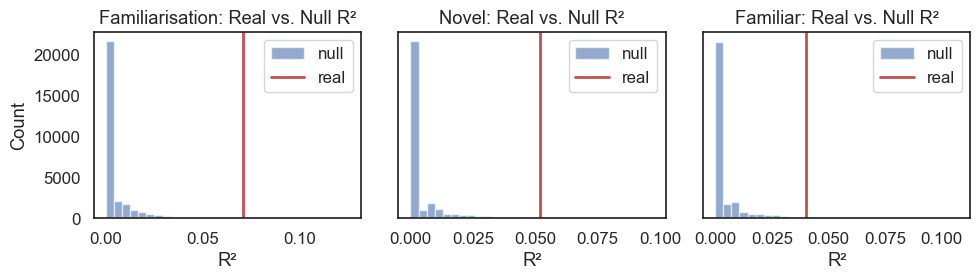

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
for cond in range(3):
    axs[cond].hist(r2_null[:, cond, :].flatten(), bins=30, alpha=0.6, label="null")
    axs[cond].axvline(np.mean(r2_scores[:, cond]), color='r', label="real", linewidth=2)
    condition_names = ["Familiarisation", "Novel", "Familiar"]
    axs[cond].set_title(f"{condition_names[cond]}: Real vs. Null R²")
    axs[cond].set_xlabel("R²")
    if cond == 0:
        axs[cond].set_ylabel("Count")
    axs[cond].legend()
plt.tight_layout()
plt.show()

In [17]:
# Median p-values per condition
median_p_per_condition = np.median(p_values, axis=0)

# Proportion of significant results per condition
sig_prop_per_condition = np.mean(p_values < 0.05, axis=0)

# Optional: label with condition names
condition_names = ['familiarisation', 'novel', 'familiar']
for name, median_p, prop_sig in zip(condition_names, median_p_per_condition, sig_prop_per_condition):
    print(f"{name}: Median p = {median_p:.3f}, % p < .05 = {prop_sig*100:.1f}%")


familiarisation: Median p = 0.018, % p < .05 = 58.6%
novel: Median p = 0.177, % p < .05 = 44.8%
familiar: Median p = 0.116, % p < .05 = 41.4%
